# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import inception_v3
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, sys
from scipy import linalg


from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint
from torchmetrics.image.fid import FrechetInceptionDistance

We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [2]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")



 Using device: cpu


In [3]:
# Helper Functions

from torchvision import datasets, transforms
def get_real_examples_per_class(n_classes=10):
    """
    Deterministically extracts one MNIST image per class (0–9)
    directly from the dataset without shuffle.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    mnist = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

    imgs, labels = [], []
    for cls in range(n_classes):
        for i in range(len(mnist)):
            if mnist[i][1] == cls:
                imgs.append(mnist[i][0])
                labels.append(cls)
                break  # stop at first match
    return torch.stack(imgs), torch.tensor(labels)




def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label (0–9).
    Ensures true label alignment for real datasets.
    """
    reps = []
    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))  
    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(generator, z_dim=100, device="cuda", n_classes=10):
    """
    Generate one representative sample per class (0–9) from cGAN.
    """
    generator.eval()
    zs = torch.randn(n_classes, z_dim, device=device)
    ys = torch.arange(n_classes, dtype=torch.long, device=device)
    imgs = generator(zs, ys).cpu()
    return imgs, ys.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cuda",
    n_classes=10,
    timesteps=200,          # used same as training
    img_size=(1, 28, 28)
):
    """
    Generate one representative diffusion sample per class (0–9), 
    using the same sampling logic as training-time generation.
    """
    from training.train_diffusion import linear_beta_schedule
    model.eval()

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, 0)

    imgs_list, labels_list = [], []

    for cls in range(n_classes):
        # Conditioning label for this class
        labels = torch.full((1,), cls, dtype=torch.long, device=device)
        imgs = torch.randn(1, *img_size).to(device)

        # Reverse diffusion loop (same as training sampler)
        for t in reversed(range(timesteps)):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
            pred_noise = model(imgs, t_tensor, labels)
            alpha = alphas[t]
            alpha_bar = alphas_cumprod[t]

            # Predict next sample
            noise = torch.randn_like(imgs) if t > 0 else torch.zeros_like(imgs)
            imgs = (1 / torch.sqrt(alpha)) * (
                imgs - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
            ) + torch.sqrt(betas[t]) * noise

        imgs_list.append(imgs[0].cpu())
        labels_list.append(cls)

    imgs_tensor = torch.stack(imgs_list)
    labels_tensor = torch.tensor(labels_list)
    return imgs_tensor, labels_tensor


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
   
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(" Comparison: Real vs cGAN vs Diffusion", fontsize=14, fontweight="bold")

    row_titles = [
        "Ground Truth",
        "CGAN",
        "Diffusion"
    ]
    row_colors = ["green", "royalblue", "darkorange"]

    # Plot each row
    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")
            axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    # Manually place row labels on figure (not as axis labels)
    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,                                   # x-position (left margin)
            0.84 - idx * 0.32,                      # y-position per row
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(left=0.12, right=0.98, top=0.9, bottom=0.05, hspace=0.3)
    plt.show()

In [4]:


def compute_fid(real_imgs, fake_imgs, device="cuda", batch_size=128):
    """
    Compute FID safely in GPU batches to prevent OOM.
    Works with TorchMetrics' FrechetInceptionDistance.
    """
    fid = FrechetInceptionDistance(normalize=True).to(device)
    fid.reset()

    def batched_update(imgs, real_flag):
        for i in tqdm(range(0, imgs.size(0), batch_size), desc=f"FID {'real' if real_flag else 'fake'}"):
            batch = imgs[i:i + batch_size].to(device, non_blocking=True)
            fid.update(batch, real=real_flag)
            torch.cuda.empty_cache()


    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2
    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()
    return score

In [5]:
# Safety clean up
torch.cuda.empty_cache()

In [6]:
# Initialize models
os.makedirs('../checkpoints', exist_ok=True)

# Initialize cGAN Generator
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
cgan_gen = Generator(z_dim=z_dim, num_classes=num_classes, img_shape=img_shape).to(device)

# Initialize Conditional UNet
diff_model = ConditionalUNet(num_classes=num_classes).to(device)

# Load latest checkpoints
load_checkpoint(cgan_gen, path='../checkpoints/cgan_generator_epochfinal.pt', map_location=device)
load_checkpoint(diff_model, path='../checkpoints/diffusion_unet_epochfinal.pt', map_location=device)

cgan_gen.eval()
diff_model.eval()


Loaded model weights from ../checkpoints/cgan_generator_epochfinal.pt
Loaded model weights from ../checkpoints/diffusion_unet_epochfinal.pt


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=

In [7]:
def generate_conditioned_samples_cgan(generator, device, z_dim=100, n_classes=10, n_per_class=100):
    """Generate class-conditioned samples from cGAN."""
    generator.eval()
    all_imgs, all_labels = [], []
    with torch.no_grad():
        for cls in range(n_classes):
            z = torch.randn(n_per_class, z_dim).to(device)
            labels = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
            imgs = generator(z, labels)
            all_imgs.append(imgs)
            all_labels.append(labels)
    return torch.cat(all_imgs), torch.cat(all_labels)

def generate_conditioned_samples_diffusion(model, device, n_classes=10, n_per_class=100, timesteps=200):
    """Generate class-conditioned samples from diffusion model."""
    model.eval()
    all_imgs, all_labels = [], []
    for cls in range(n_classes):
        class_labels = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
        imgs, labels = sample_images(model, device, num_samples=n_per_class,
                                     num_classes=n_classes, timesteps=timesteps,
                                     class_labels=class_labels)
        all_imgs.append(imgs)
        all_labels.append(labels)
    return torch.cat(all_imgs), torch.cat(all_labels)

real_imgs, real_labels = get_real_examples_per_class()

# Generate cGAN samples
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, device=device)
print(f'cGAN samples: {cgan_imgs.shape}')

# Generate diffusion samples
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(diff_model, device=device)
print(f'Diffusion samples: {diff_imgs.shape}')


cGAN samples: torch.Size([1000, 1, 28, 28])


Diffusion samples: torch.Size([1000, 1, 28, 28])


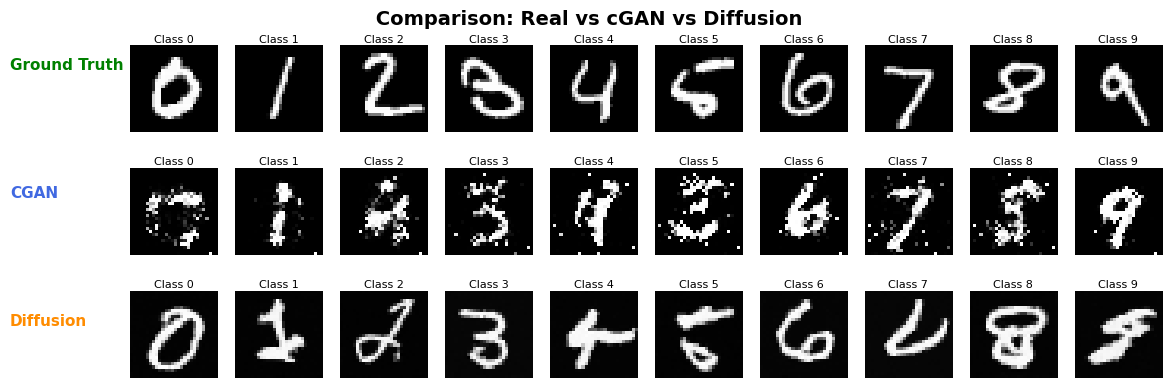

In [8]:
# Plot visual comparison: Real vs cGAN vs Diffusion
# Get representative images (one per class)
real_reps = get_representative_images(real_imgs, real_labels)
cgan_reps = get_representative_images(cgan_imgs, cgan_labels)
diff_reps = get_representative_images(diff_imgs, diff_labels)

plot_real_cgan_diffusion(real_reps, cgan_reps, diff_reps)


In [9]:

fid = FrechetInceptionDistance(normalize=True).to(device)
fid.reset()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth


  0%|                                               | 0.00/91.2M [00:00<?, ?B/s]

 11%|████▏                                 | 10.1M/91.2M [00:00<00:00, 86.1MB/s]

 29%|███████████▎                           | 26.5M/91.2M [00:00<00:00, 132MB/s]

 44%|█████████████████▏                     | 40.1M/91.2M [00:00<00:00, 112MB/s]

 59%|███████████████████████▏               | 54.2M/91.2M [00:00<00:00, 124MB/s]

 75%|█████████████████████████████▏         | 68.1M/91.2M [00:00<00:00, 131MB/s]

 89%|██████████████████████████████████▋    | 81.0M/91.2M [00:00<00:00, 115MB/s]

100%|███████████████████████████████████████| 91.2M/91.2M [00:00<00:00, 116MB/s]

In [10]:
torch.cuda.empty_cache()

In [11]:
# Choose subset for FID computation
n_fid = min(1000, len(cgan_imgs), len(diff_imgs))

# Get real images for FID
real_test = datasets.MNIST(root='../data', train=False, download=True,
                           transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]))
real_loader = DataLoader(real_test, batch_size=n_fid, shuffle=True)
real_subset, _ = next(iter(real_loader))
real_subset = real_subset[:n_fid]

cgan_subset = cgan_imgs[:n_fid].detach().cpu()
diff_subset = diff_imgs[:n_fid].detach().cpu()

print(f'FID evaluation on {n_fid} samples each')
print(f'Real: {real_subset.shape}, cGAN: {cgan_subset.shape}, Diffusion: {diff_subset.shape}')


FID evaluation on 1000 samples each
Real: torch.Size([1000, 1, 28, 28]), cGAN: torch.Size([1000, 1, 28, 28]), Diffusion: torch.Size([1000, 1, 28, 28])


In [12]:
# Compute FID for cGAN
cgan_fid = compute_fid(real_subset, cgan_subset, device=device)

# Compute FID for Diffusion
diff_fid = compute_fid(real_subset, diff_subset, device=device)

print(f' cGAN FID: {cgan_fid:.2f}')
print(f'Diffusion FID: {diff_fid:.2f}')


FID real:   0%|                                           | 0/8 [00:00<?, ?it/s]

FID real:  12%|████▍                              | 1/8 [00:04<00:30,  4.32s/it]

FID real:  25%|████████▊                          | 2/8 [00:08<00:25,  4.30s/it]

FID real:  38%|█████████████▏                     | 3/8 [00:12<00:21,  4.25s/it]

FID real:  50%|█████████████████▌                 | 4/8 [00:17<00:17,  4.26s/it]

...

FID fake:  75%|██████████████████████████▎        | 6/8 [00:25<00:08,  4.27s/it]

FID fake:  88%|██████████████████████████████▋    | 7/8 [00:29<00:04,  4.29s/it]

FID fake: 100%|███████████████████████████████████| 8/8 [00:33<00:00,  4.01s/it]

FID fake: 100%|███████████████████████████████████| 8/8 [00:33<00:00,  4.17s/it]

 cGAN FID: 256.69
Diffusion FID: 29.32


In [13]:
# FID Score Analysis
print('FID Score Analysis')
print('=' * 50)
print(f'cGAN FID: {cgan_fid:.2f}')
print(f'Diffusion FID: {diff_fid:.2f}')
print()
if diff_fid < cgan_fid:
    print('The Diffusion model achieves a LOWER FID score, indicating better')
    print('image quality and diversity compared to the cGAN.')
    print('This is expected: diffusion models learn a more stable denoising process,')
    print('while GANs can suffer from mode collapse and training instability.')
else:
    print('The cGAN achieves a LOWER FID score, indicating competitive or better')
    print('image quality. This can happen with well-tuned GAN training and sufficient epochs.')
print()
print('Lower FID = better quality and diversity.')
print('FID measures the distance between real and generated image distributions')
print('using features from a pretrained Inception network.')


FID Score Analysis
cGAN FID: 256.69
Diffusion FID: 29.32

The Diffusion model achieves a LOWER FID score, indicating better
image quality and diversity compared to the cGAN.
This is expected: diffusion models learn a more stable denoising process,
while GANs can suffer from mode collapse and training instability.

Lower FID = better quality and diversity.
FID measures the distance between real and generated image distributions
using features from a pretrained Inception network.


### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [14]:
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, device=device, n_classes=10)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_classes=10, timesteps=200
)


In [15]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [16]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [17]:
def normalize_synthetic(imgs):
    imgs = imgs.clone()
    imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # [0,1]
    imgs = imgs * 2 - 1  # [-1,1]
    return imgs

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print("Unique labels in CGAN:", torch.unique(cgan_labels))
print("Unique labels in Diffusion:", torch.unique(diff_labels))

Unique labels in CGAN: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Unique labels in Diffusion: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [18]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [19]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [20]:

cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=20)
cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=20)

cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 1.9135


Epoch 2: loss = 0.3880


Epoch 3: loss = 0.0057


Epoch 4: loss = 0.0001


Epoch 5: loss = 0.0000


...

Epoch 14: loss = 0.3027
Epoch 15: loss = 0.2685


Epoch 16: loss = 0.2625
Epoch 17: loss = 0.2078


Epoch 18: loss = 0.1794
Epoch 19: loss = 0.1345


Epoch 20: loss = 0.1077


Classifier trained on cGAN data → Test accuracy: 0.377
Classifier trained on Diffusion data → Test accuracy: 0.905
